# Student Performance Prediction — Final Grade (G3)

**Objective:** predict a student's final grade (G3, on a 0–20 scale) from background, school-life and prior-grade features.

**Data:** Student Performance — UCI Machine Learning Repository (649 records, mathematics and Portuguese language courses).

**Models compared:** Linear Regression · Random Forest · HistGradientBoosting  
**Metrics:** RMSE · MAE · R²


## 1. Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 2. Loading the data


In [2]:
DATA_FILE = Path('StudentPerformance.csv')

if not DATA_FILE.exists():
    from ucimlrepo import fetch_ucirepo
    student = fetch_ucirepo(id=320)
    student.data.original.to_csv(DATA_FILE, index=False, encoding='utf-8-sig')

raw = pd.read_csv(DATA_FILE, encoding='utf-8-sig')
display(raw.head())


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Data quality checks


In [3]:
raw.info()
print('\nMissing values:', int(raw.isnull().sum().sum()))
print('Duplicate rows:', int(raw.duplicated().sum()))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [4]:
display(raw.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
age,649.0,16.74,1.22,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.51,1.13,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.31,1.10,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.57,0.75,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.93,0.83,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.22,0.59,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.93,0.96,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.18,1.05,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.18,1.18,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.50,0.92,1.0,1.0,1.0,2.0,5.0


In [5]:
display(raw['G3'].agg(['count', 'mean', 'std', 'min', 'max']).round(2))


count    649.00
mean      11.91
std        3.23
min        0.00
max       19.00
Name: G3, dtype: float64

Grades use the Portuguese 0–20 scale. G1 and G2 are the first- and second-period grades; G3 is the final grade to predict.


## 4. Exploratory analysis


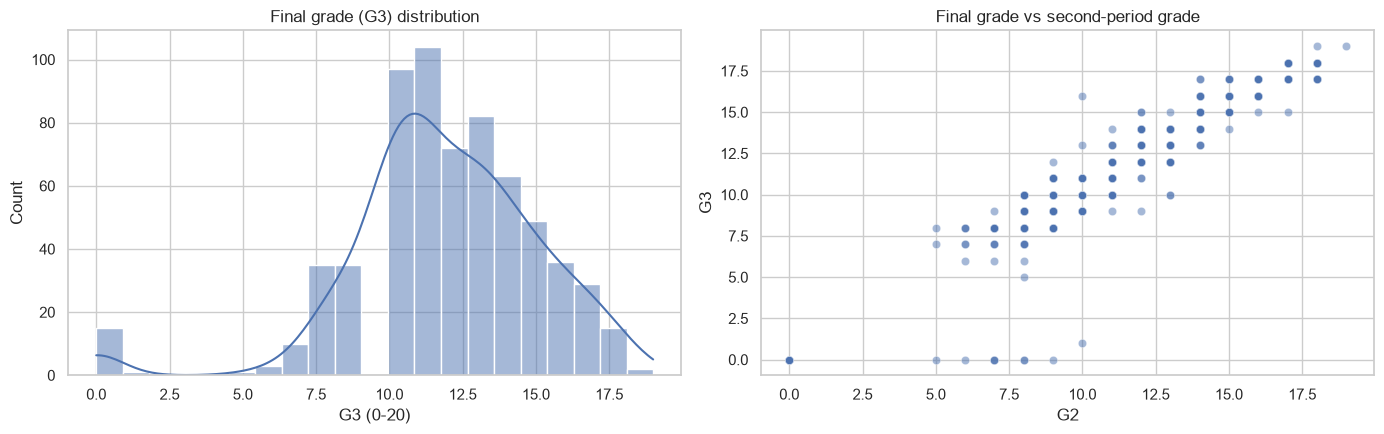

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(raw['G3'], bins=21, kde=True, ax=axes[0])
axes[0].set_title('Final grade (G3) distribution')
axes[0].set_xlabel('G3 (0-20)')

sns.scatterplot(data=raw, x='G2', y='G3', alpha=0.5, ax=axes[1])
axes[1].set_title('Final grade vs second-period grade')
axes[1].set_xlabel('G2')
axes[1].set_ylabel('G3')
plt.tight_layout()
plt.show()


Prior grades (G1, G2) track the final grade closely; background factors add smaller adjustments.


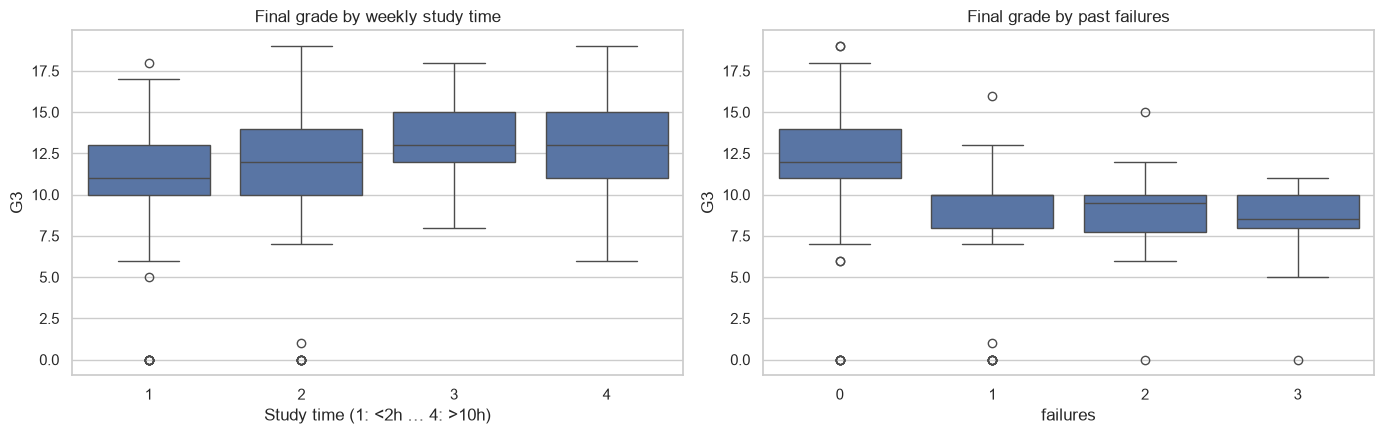

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=raw, x='studytime', y='G3', ax=axes[0])
axes[0].set_title('Final grade by weekly study time')
axes[0].set_xlabel('Study time (1: <2h … 4: >10h)')

sns.boxplot(data=raw, x='failures', y='G3', ax=axes[1])
axes[1].set_title('Final grade by past failures')
plt.tight_layout()
plt.show()


## 5. Feature selection

All 30 background and school-life features are kept, including prior grades G1 and G2. A robustness test (section 13) measures performance without them.

In [8]:
TARGET = 'G3'

NUM = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'G1', 'G2']
CAT = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic']

ALL_FEATURES = NUM + CAT
assert all(c in raw.columns for c in ALL_FEATURES + [TARGET])


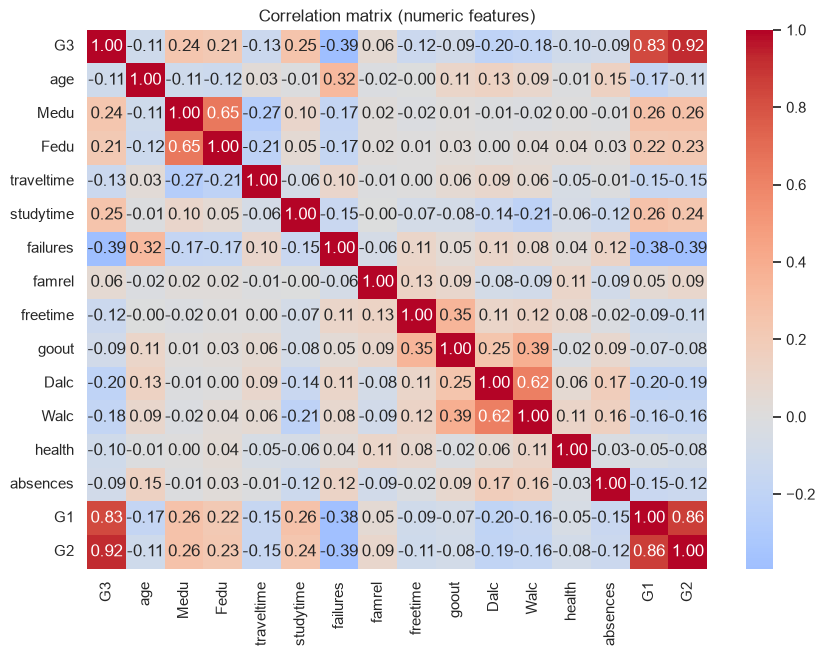

In [9]:
num_corr = raw[[TARGET] + NUM].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric features)')
plt.show()


## 6. Train / test split

Random 80% / 20% split (no time component in this dataset).

In [10]:
X = raw[ALL_FEATURES]
y = raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f'Train: {len(X_train)} rows')
print(f'Test:  {len(X_test)} rows')


Train: 519 rows
Test:  130 rows


## 7. Modeling pipelines

Preprocessing is built into the pipelines (imputation + scaling / one-hot encoding), fitted on the training set only. Grades are clipped to the 0–20 scale at prediction time.

In [11]:
def make_preprocessor(num_cols, cat_cols):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler())])
    categorical = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer([('num', numeric, num_cols),
                              ('cat', categorical, cat_cols)])


def build_pipelines(drop=()):
    keep = lambda cols: [c for c in cols if c not in drop]
    linear = Pipeline([
        ('preprocessor', make_preprocessor(keep(NUM), keep(CAT))),
        ('model', LinearRegression()),
    ])
    forest = Pipeline([
        ('preprocessor', make_preprocessor(keep(NUM), keep(CAT))),
        ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
    ])
    boosting = Pipeline([
        ('preprocessor', make_preprocessor(keep(NUM), keep(CAT))),
        ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ])
    return {'Linear Regression': linear, 'Random Forest': forest, 'HistGradientBoosting': boosting}


pipelines = build_pipelines()


## 8. Cross-validation


In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'}

cv_rows = []
for name, pipe in pipelines.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'RMSE train': -res['train_rmse'].mean(),
        'RMSE CV': -res['test_rmse'].mean(),
        'MAE CV': -res['test_mae'].mean(),
        'R2 train': res['train_r2'].mean(),
        'R2 CV': res['test_r2'].mean(),
    })

cv_base = pd.DataFrame(cv_rows).set_index('Model')
display(cv_base.round(3))


,RMSE train,RMSE CV,MAE CV,R2 train,R2 CV
Model,,,,,
Linear Regression,1.204,1.332,0.885,0.862,0.826
Random Forest,0.490,1.364,0.875,0.977,0.813
HistGradientBoosting,0.615,1.417,0.938,0.964,0.798


## 9. Hyperparameter tuning

Randomized search (`RandomizedSearchCV`) with 5-fold cross-validation, on the training set only.

In [13]:
param_rf = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [None, 8, 15],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_features': [0.5, 0.7, 1.0],
}
param_hgb = {
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_iter': [200, 300],
    'model__max_leaf_nodes': [15, 31],
    'model__min_samples_leaf': [10, 20],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}

searches = {}
for name, grid in [('Random Forest', param_rf), ('HistGradientBoosting', param_hgb)]:
    search = RandomizedSearchCV(
        pipelines[name], grid, n_iter=10, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    searches[name] = search

display(pd.DataFrame({
    'Model': list(searches.keys()),
    'Best params': [s.best_params_ for s in searches.values()],
    'RMSE CV': [-s.best_score_ for s in searches.values()],
}).set_index('Model').round(3))


,Best params,RMSE CV
Model,,
Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",1.287
HistGradientBoosting,"{'model__min_samples_leaf': 10, 'model__max_le...",1.390


## 10. Test-set evaluation


In [14]:
final_models = {
    'Linear Regression': pipelines['Linear Regression'].fit(X_train, y_train),
    'Random Forest': searches['Random Forest'].best_estimator_,
    'HistGradientBoosting': searches['HistGradientBoosting'].best_estimator_,
}

def predict_clipped(model, X_):
    return np.clip(model.predict(X_), 0, 20)

rows, preds_test = [], {}
for name, model in final_models.items():
    p_tr, p_te = predict_clipped(model, X_train), predict_clipped(model, X_test)
    preds_test[name] = p_te
    rows.append({
        'Model': name,
        'RMSE': rmse(y_test, p_te),
        'MAE': mean_absolute_error(y_test, p_te),
        'R2': r2_score(y_test, p_te),
        'R2 train': r2_score(y_train, p_tr),
    })

results = pd.DataFrame(rows).set_index('Model')
display(results.round(3))


,RMSE,MAE,R2,R2 train
Model,,,,
Linear Regression,1.215,0.765,0.849,0.858
Random Forest,1.204,0.727,0.851,0.961
HistGradientBoosting,1.266,0.738,0.836,0.962


In [15]:
cv_rmse = {
    'Linear Regression': cv_base.loc['Linear Regression', 'RMSE CV'],
    'Random Forest': -searches['Random Forest'].best_score_,
    'HistGradientBoosting': -searches['HistGradientBoosting'].best_score_,
}
best_name = min(cv_rmse, key=cv_rmse.get)
print('Selected model:', best_name)


Selected model: Random Forest


## 11. Prediction diagnostics


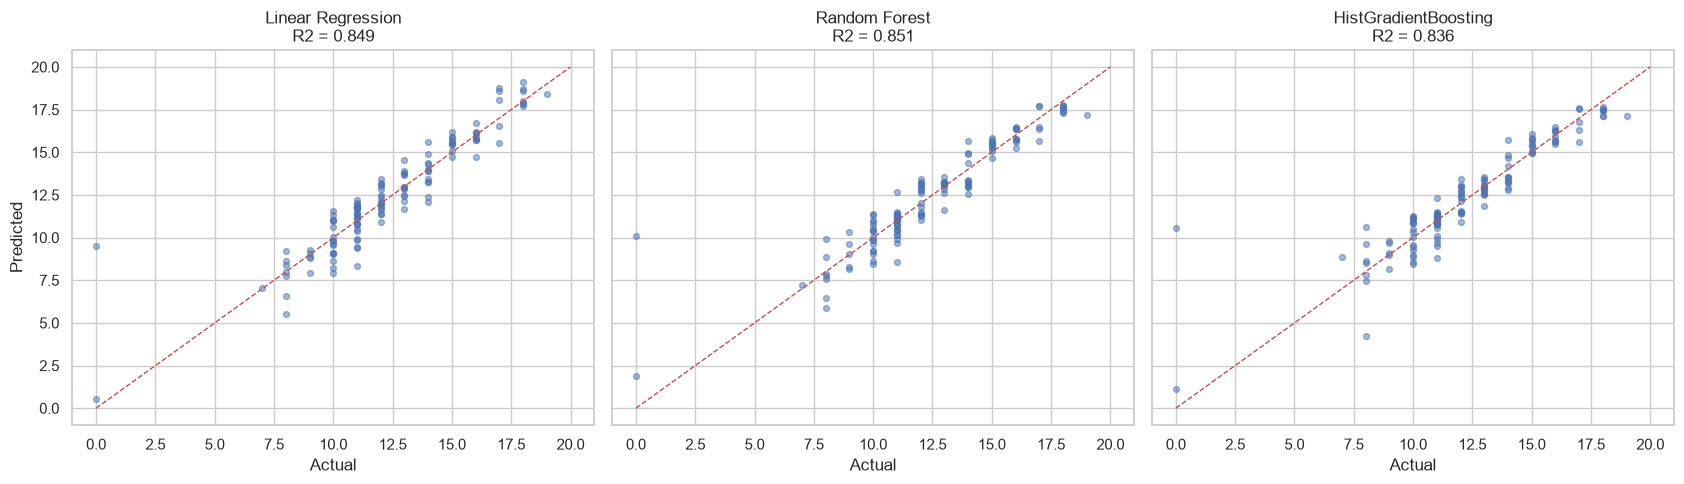

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
lim = 20
for ax, (name, p) in zip(axes, preds_test.items()):
    ax.scatter(y_test, p, alpha=0.5, s=18)
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f'{name}\nR2 = {r2_score(y_test, p):.3f}')
    ax.set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
plt.tight_layout()
plt.show()


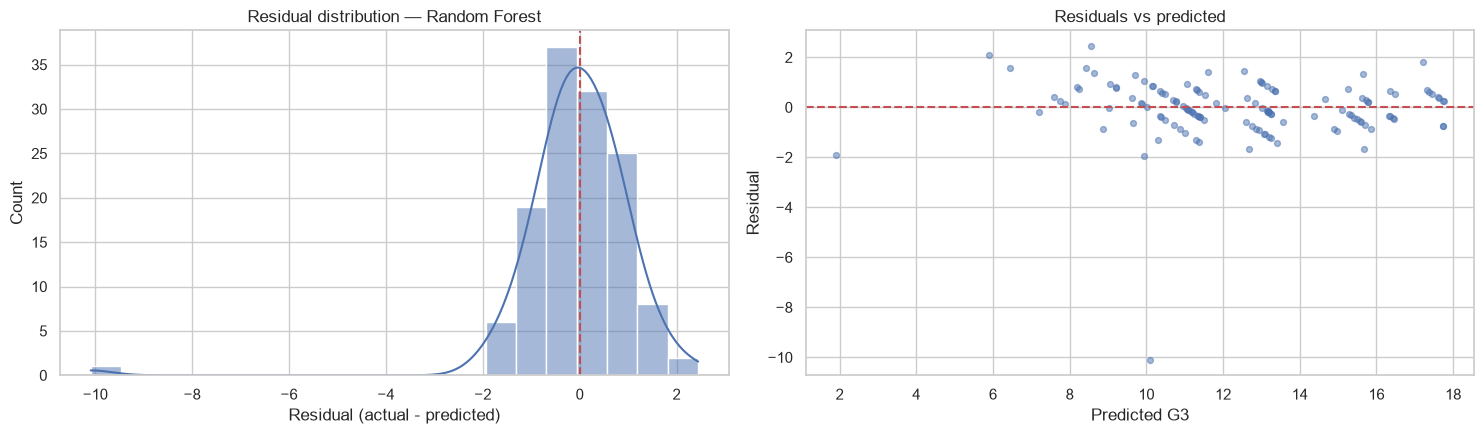

In [17]:
best_pred = preds_test[best_name]
resid = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(resid, bins=20, kde=True, ax=axes[0])
axes[0].axvline(0, color='r', ls='--')
axes[0].set_title(f'Residual distribution — {best_name}')
axes[0].set_xlabel('Residual (actual - predicted)')

axes[1].scatter(best_pred, resid, alpha=0.5, s=18)
axes[1].axhline(0, color='r', ls='--')
axes[1].set_title('Residuals vs predicted')
axes[1].set_xlabel('Predicted G3')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()


## 12. Feature importance


,Feature,RMSE increase if permuted,Std
14,G2,2.341,0.185
13,G1,0.273,0.070
12,absences,0.089,0.037
0,age,0.017,0.007
5,failures,0.014,0.007
1,Medu,0.013,0.011
11,health,0.008,0.006
16,sex,0.007,0.005
25,famsup,0.007,0.005
31,romantic,0.007,0.003


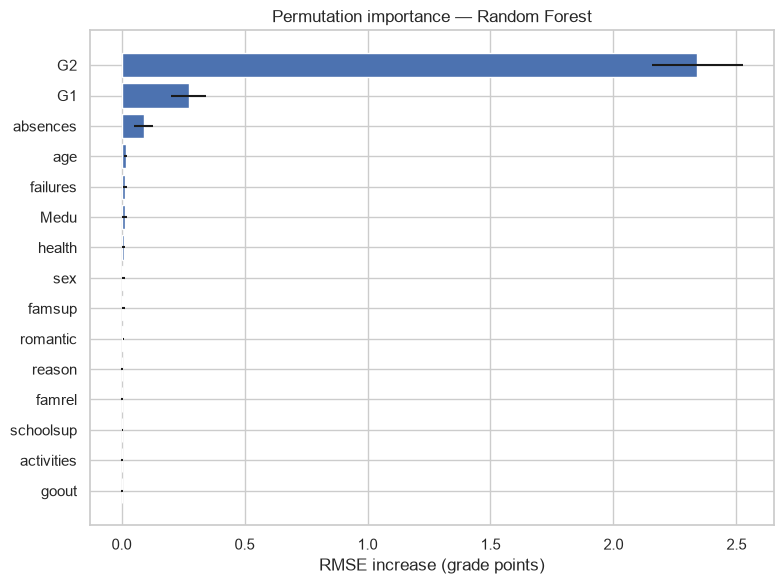

In [18]:
perm = permutation_importance(
    final_models[best_name], X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
imp = (pd.DataFrame({'Feature': X_test.columns,
                     'RMSE increase if permuted': perm.importances_mean,
                     'Std': perm.importances_std})
       .sort_values('RMSE increase if permuted', ascending=False))
display(imp.head(15).round(3))

plt.figure(figsize=(8, 6))
top = imp.head(15).iloc[::-1]
plt.barh(top['Feature'], top['RMSE increase if permuted'], xerr=top['Std'])
plt.xlabel('RMSE increase (grade points)')
plt.title(f'Permutation importance — {best_name}')
plt.tight_layout()
plt.show()


## 13. Robustness test: prediction without prior grades

G1 and G2 dominate the prediction. This test retrains every model without them to measure how much signal the background features carry on their own.

In [19]:
no_prior = build_pipelines(drop=('G1', 'G2'))
rows = []
for name, pipe in no_prior.items():
    if name in searches:
        pipe.set_params(**{k: v for k, v in searches[name].best_params_.items()
                           if k in pipe.get_params()})
    pipe.fit(X_train, y_train)
    p = predict_clipped(pipe, X_test)
    rows.append({'Model': name, 'RMSE': rmse(y_test, p), 'MAE': mean_absolute_error(y_test, p),
                 'R2': r2_score(y_test, p)})
display(pd.DataFrame(rows).set_index('Model').round(3))


,RMSE,MAE,R2
Model,,,
Linear Regression,2.862,2.156,0.160
Random Forest,2.771,2.039,0.213
HistGradientBoosting,2.735,2.052,0.233


## 14. Prediction examples

Three new student profiles. The interval uses the 10% / 90% residual quantiles, clipped to 0–20.

In [20]:
q_low, q_high = np.quantile(resid, [0.10, 0.90])


def predict_grade(model, new_df, q=(q_low, q_high)):
    pred = np.clip(model.predict(new_df[ALL_FEATURES]), 0, 20)
    low, high = np.clip(pred + q[0], 0, 20), np.clip(pred + q[1], 0, 20)
    out = new_df[['school', 'sex', 'age', 'studytime', 'failures', 'absences', 'G1', 'G2']].copy()
    out['Prediction'] = np.round(pred, 1)
    out['Low (10%)'] = np.round(low, 1)
    out['High (90%)'] = np.round(high, 1)
    return out


In [21]:
typical = dict(raw[ALL_FEATURES].mode().iloc[0])

new_students = pd.DataFrame([
    {**typical, 'sex': 'F', 'studytime': 4, 'failures': 0, 'absences': 0, 'G1': 16, 'G2': 17},
    {**typical, 'sex': 'M', 'studytime': 2, 'failures': 0, 'absences': 4, 'G1': 11, 'G2': 12},
    {**typical, 'sex': 'M', 'studytime': 1, 'failures': 2, 'absences': 14, 'G1': 7, 'G2': 8},
])
new_students['Profile'] = ['Strong student', 'Average student', 'At-risk student']

result = predict_grade(final_models[best_name], new_students)
result.insert(0, 'Profile', new_students['Profile'].values)
display(result)


,Profile,school,sex,age,studytime,failures,absences,G1,G2,Prediction,Low (10%),High (90%)
0,Strong student,GP,F,17,4,0,0,16,17,17.4,16.4,18.4
1,Average student,GP,M,17,2,0,4,11,12,12.8,11.8,13.8
2,At-risk student,GP,M,17,1,2,14,7,8,7.9,6.9,8.9


## 15. Saving the model


In [22]:
final_pipeline = clone(final_models[best_name])
final_pipeline.fit(X, y)

MODEL_FILE = 'student_model_v1.pkl'
artifact = {
    'model': final_pipeline,
    'model_name': best_name,
    'features': ALL_FEATURES,
    'numeric': NUM,
    'categorical': CAT,
    'residual_quantiles_10_90': (float(q_low), float(q_high)),
    'target_range': (0, 20),
    'input_format': 'raw dataset columns (same names as StudentPerformance.csv)',
}
joblib.dump(artifact, MODEL_FILE)

loaded = joblib.load(MODEL_FILE)
before = predict_grade(final_pipeline, new_students)['Prediction'].tolist()
after = predict_grade(loaded['model'], new_students, q=loaded['residual_quantiles_10_90'])['Prediction'].tolist()
assert before == after
print(f"Model '{best_name}' saved: {MODEL_FILE}")


Model 'Random Forest' saved: student_model_v1.pkl


## 16. Conclusion

- The best model (selected on cross-validation RMSE) predicts the final grade within a few points on unseen students.
- Prior grades (G2, G1) are the strongest predictors; background features (failures, absences, study time) adjust the prediction.
- The no-prior-grades test shows how much signal remains without G1/G2 — the realistic early-warning scenario.

**Possible improvements:** separate models per subject, threshold-based at-risk classification, more school years.